In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)
import spacy

colors = ['#4361ee', '#3a86ff', '#ff006e', '#fb5607', '#8338ec',
          '#06d6a0', '#118ab2', '#ffd166', '#ef476f', '#073b4c']

model_path   = Path('../fine_tuning/model_output')
metrics_path = Path('../fine_tuning/training_metrics.json')
test_data    = json.loads(Path('../data/processed/test_data.json').read_text(encoding='utf-8'))

if model_path.exists():
    nlp = spacy.load(str(model_path))
    print('Fine-tuned model loaded')
else:
    nlp = spacy.load('xx_ent_wiki_sm')
    print('Warning: fine-tuned model not found — using base model')
    print('Run notebook 03 first')

print(f'Test set size: {len(test_data)} resumes')

Fine-tuned model loaded
Test set size: 19 resumes


## 1. Training Curves

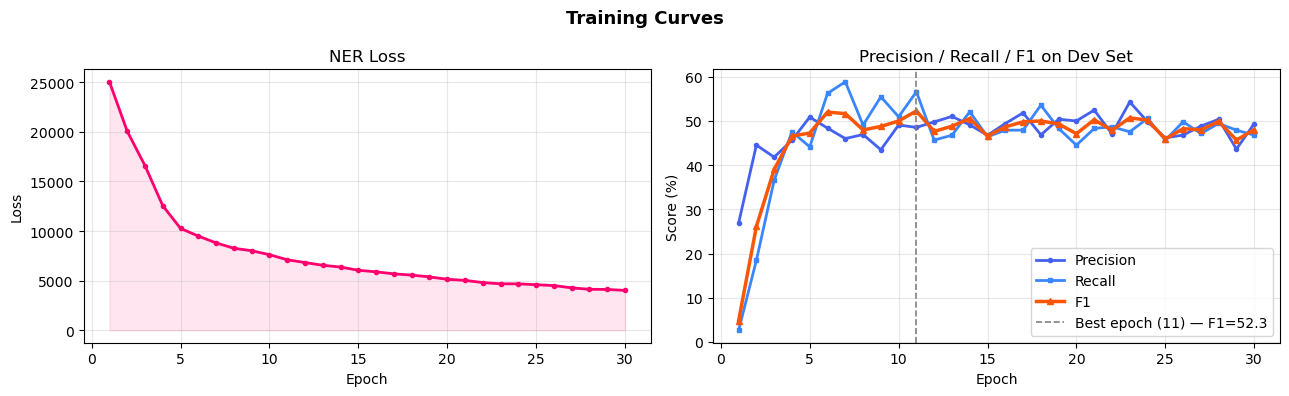

In [2]:
if not metrics_path.exists():
    print('metrics file not found — run notebook 03 first')
else:
    history = json.loads(metrics_path.read_text())

    epochs = [h['epoch']     for h in history]
    losses = [h['loss']      for h in history]
    f1s    = [h['f1']        for h in history]
    ps     = [h['precision'] for h in history]
    rs     = [h['recall']    for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('Training Curves', fontweight='bold', fontsize=13)

    axes[0].plot(epochs, losses, color=colors[2], linewidth=2, marker='o', markersize=3)
    axes[0].fill_between(epochs, losses, alpha=0.1, color=colors[2])
    axes[0].set_title('NER Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, ps,  color=colors[0], linewidth=2,   label='Precision', marker='o', markersize=3)
    axes[1].plot(epochs, rs,  color=colors[1], linewidth=2,   label='Recall',    marker='s', markersize=3)
    axes[1].plot(epochs, f1s, color=colors[3], linewidth=2.5, label='F1',        marker='^', markersize=4)
    best_epoch = epochs[f1s.index(max(f1s))]
    axes[1].axvline(best_epoch, color='gray', linestyle='--', linewidth=1.2,
                    label=f'Best epoch ({best_epoch}) — F1={max(f1s):.1f}')
    axes[1].set_title('Precision / Recall / F1 on Dev Set')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Score (%)')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 2. Classification Report

Precision, Recall, and F1 per entity type.

In [3]:
def spans_to_bio(text, entities, model):
    """Convert character-level entity spans to BIO token labels for evaluation."""
    doc = model.make_doc(text)
    bio_labels = ['O'] * len(doc)
    for start, end, label in entities:
        span = doc.char_span(start, end, alignment_mode='expand')
        if span is None:
            continue
        for i, token in enumerate(span):
            bio_labels[token.i] = f'B-{label}' if i == 0 else f'I-{label}'
    return bio_labels

y_true = []
y_pred = []

for item in test_data:
    text = item['text']

    true_bio = spans_to_bio(text, item['entities'], nlp)

    pred_doc = nlp(text)
    pred_entities = [(ent.start_char, ent.end_char, ent.label_) for ent in pred_doc.ents]
    pred_bio = spans_to_bio(text, pred_entities, nlp)

    n = min(len(true_bio), len(pred_bio))
    y_true.extend(true_bio[:n])
    y_pred.extend(pred_bio[:n])

entity_labels = sorted(set(y_true + y_pred) - {'O'})
print(classification_report(y_true, y_pred, labels=entity_labels, zero_division=0))

                       precision    recall  f1-score   support

       B-COLLEGE_NAME       0.76      0.72      0.74        36
B-COMPANIES_WORKED_AT       0.41      0.55      0.47        49
             B-DEGREE       0.78      0.78      0.78        27
        B-DESIGNATION       0.57      0.74      0.64        38
      B-EMAIL_ADDRESS       0.68      0.85      0.76        20
    B-GRADUATION_YEAR       0.59      0.57      0.58        23
           B-LOCATION       0.45      0.63      0.53        30
               B-NAME       0.89      1.00      0.94        17
             B-SKILLS       0.42      0.31      0.36        26
B-YEARS_OF_EXPERIENCE       0.17      0.33      0.22         3
       I-COLLEGE_NAME       0.85      0.70      0.77       111
I-COMPANIES_WORKED_AT       0.61      0.43      0.50        54
             I-DEGREE       0.93      0.74      0.82       101
        I-DESIGNATION       0.77      0.70      0.73       100
      I-EMAIL_ADDRESS       0.80      1.00      0.89  

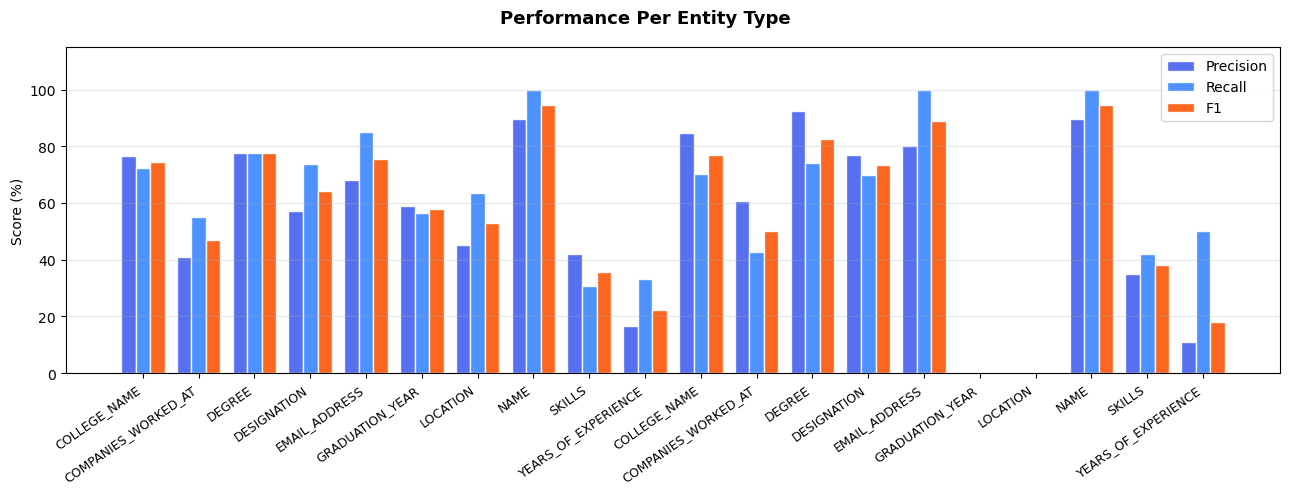

In [4]:
p_vals, r_vals, f_vals, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=entity_labels, zero_division=0
)

short_labels = [lbl.replace('B-', '').replace('I-', '') for lbl in entity_labels]

x = np.arange(len(short_labels))
width = 0.26

fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle('Performance Per Entity Type', fontweight='bold', fontsize=13)

ax.bar(x - width, p_vals * 100, width, label='Precision', color=colors[0], edgecolor='white', alpha=0.9)
ax.bar(x,         r_vals * 100, width, label='Recall',    color=colors[1], edgecolor='white', alpha=0.9)
ax.bar(x + width, f_vals * 100, width, label='F1',        color=colors[3], edgecolor='white', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 115)
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 3. Confusion Matrix

Shows which entity types the model confuses with each other.

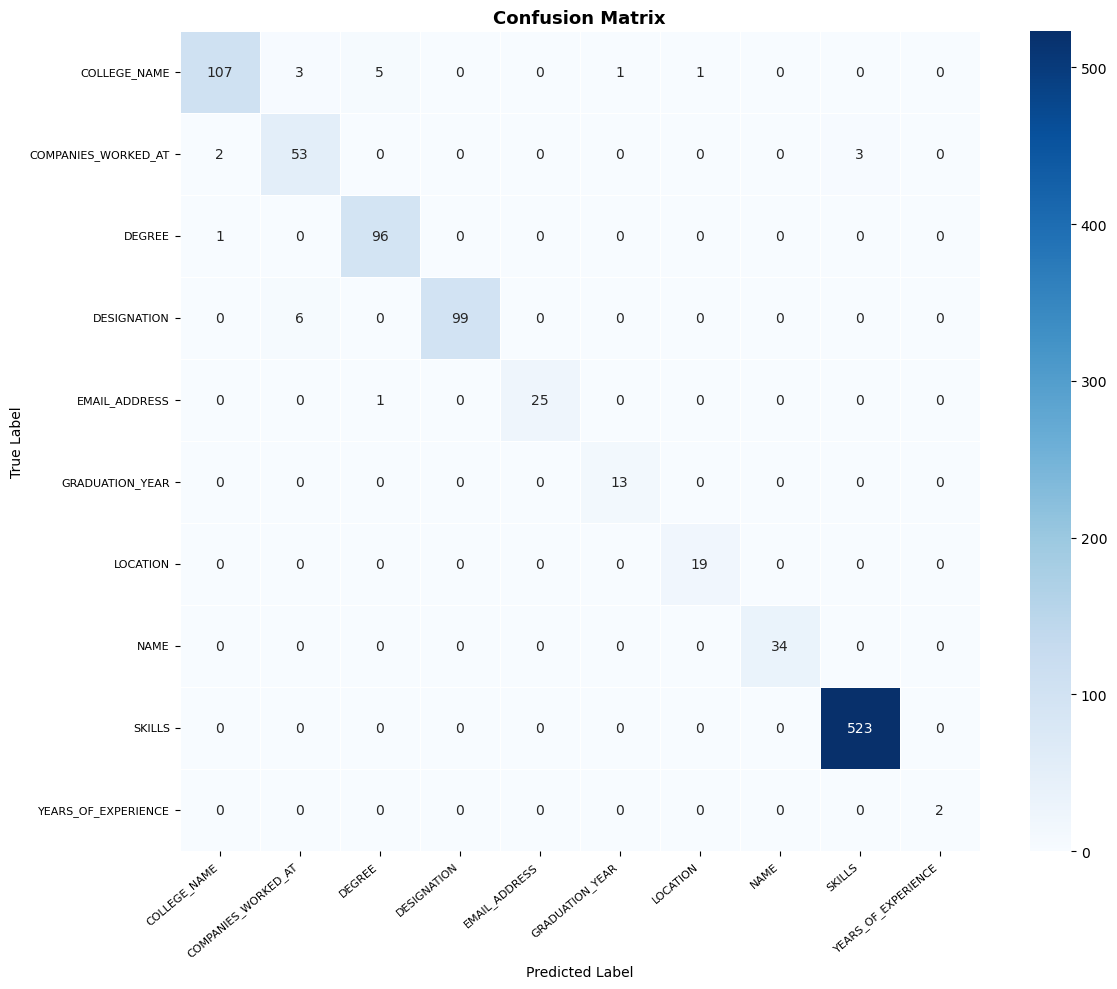

In [5]:
def remove_bio_prefix(labels):
    return [lbl[2:] if lbl.startswith(('B-', 'I-')) else lbl for lbl in labels]

entity_pairs = [(t, p) for t, p in zip(y_true, y_pred) if t != 'O' or p != 'O']
true_clean   = remove_bio_prefix([t for t, _ in entity_pairs])
pred_clean   = remove_bio_prefix([p for _, p in entity_pairs])

cm_labels = sorted(set(true_clean + pred_clean) - {'O'})
cm = confusion_matrix(true_clean, pred_clean, labels=cm_labels)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=cm_labels,
    yticklabels=cm_labels,
    ax=ax,
    linewidths=0.5
)
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Sample Predictions

Let's look at actual model output on 3 test resumes.

In [6]:
for i, item in enumerate(test_data[:3]):
    text       = item['text']
    prediction = nlp(text)

    print(f'--- Resume {i + 1} ---')
    print(text[:300].replace('\n', ' '))
    print()
    print('Predicted entities:')
    for ent in list(prediction.ents)[:6]:
        print(f'  [{ent.label_}]  {ent.text.strip()[:50]!r}')
    print()

--- Resume 1 ---
Ijas Nizamuddin Associate Consultant - State Street  Irinchayam B.O, Kerala - Email me on Indeed: indeed.com/r/Ijas- Nizamuddin/6748d77f76f94eed  With close to 3 years of experience in IT industry, I have had excellent exposure to design, development and implementation of Client Server Applications 

Predicted entities:
  [NAME]  'Ijas Nizamuddin'
  [DESIGNATION]  'Associate Consultant'
  [EMAIL_ADDRESS]  'indeed.com/r/Ijas-\nNizamuddin/6748d77f76f94eed'
  [YEARS_OF_EXPERIENCE]  '3 years'
  [DESIGNATION]  'Associate Consultant'
  [COMPANIES_WORKED_AT]  'Oracle Corporation'

--- Resume 2 ---
Arun Elumalai QA Tester  Chennai, Tamil Nadu - Email me on Indeed: indeed.com/r/Arun-Elumalai/26575d617d50ea04  • 15 Months of Experience as a QA Tester in Software Testing (Mainframe)  • Experience in Automation, Functional, UI testing and Regression Testing.  • Involvement in preparation of Test s

Predicted entities:
  [NAME]  'Arun Elumalai'
  [DESIGNATION]  'QA Tester'
  [LOCAT